# End-to-End Machine Learning: Autism Spectrum Disorder (ASD) Prediction — Fixed

This notebook predicts whether a person is likely to show **Autism Spectrum Disorder (ASD)** traits, based on demographic information and the **AQ-10** screening questionnaire.

### What was fixed in this version
1. **Data loading** — the original notebook pulled files from Google Drive links, which don't work offline/without internet access. It now loads directly from the files you uploaded (`train.csv`, `Autism_Data.csv`, `Autism_Child_Data.csv`, `Autism_Adolescent_Data.csv`, `Autism-Adult-Data.arff`).
2. **Class imbalance** — the original approach duplicated (bootstrapped) minority-class rows, which just memorizes repeated rows and overfits. This version uses **SMOTE** (synthetic minority oversampling) applied *only inside the training fold* (via an `imblearn` pipeline), so the test set is never touched and no synthetic leakage occurs.
3. **Accuracy / leakage** — the engineered `result_check` column (and the original `result` column) is just the row-wise sum of `A1_Score`…`A10_Score`. Keeping it as a feature adds pure duplicate/collinear information already present in the individual A-scores, so it's dropped. Previously useful features (`age`, `gender`, `jundice`, `used_app_before`) that were being dropped before training are now kept, since they add real signal.
4. **Model selection & tuning** — added `GridSearchCV` (5-fold stratified CV, optimizing F1) for each candidate model, comparing Logistic Regression, Random Forest, SVM (RBF), and XGBoost, and automatically picking the best one.
5. **Model saving** — the final tuned pipeline (preprocessing + classifier, all in one `sklearn`/`imblearn` `Pipeline`) is saved to disk with `joblib`, so it can be reloaded later without retraining.
6. **Other fixes** — removed duplicate/dead code cells, fixed inconsistent `id`/`jundice` column names across the 4 raw sources, fixed a stray outlier age value, cleaned up categorical text (extra whitespace, `?` placeholders), and removed unused/duplicated imports.


## 0. Setup — install compatible package versions

**Why:** this notebook uses `imbalanced-learn`'s `Pipeline` to run SMOTE safely inside cross-validation. If your installed `imbalanced-learn` is older than your `scikit-learn`, you'll hit:

```
AttributeError: 'Pipeline' object has no attribute '_check_fit_params'
```

That's a version-compatibility bug, not a problem with the notebook logic — newer `scikit-learn` versions renamed some internal `Pipeline` methods, and older `imbalanced-learn` releases still call the old names. Run the cell below once to fix it (safe to re-run any time), then **restart the kernel** before running the rest of the notebook so the upgraded packages are actually loaded.

In [33]:
import subprocess, sys

packages = ["scikit-learn>=1.4", "imbalanced-learn>=0.12", "xgboost", "joblib"]

def pip_install(extra_args=None):
    cmd = [sys.executable, "-m", "pip", "install", "--upgrade", *packages]
    if extra_args:
        cmd += extra_args
    subprocess.check_call(cmd)

# Plain pip install first (works on Windows/macOS and most environments).
# Some Linux setups (e.g. Debian/Ubuntu "externally managed" Python) reject this
# unless --break-system-packages is passed, so fall back to that automatically.
try:
    pip_install()
except subprocess.CalledProcessError:
    pip_install(extra_args=["--break-system-packages"])

import sklearn, imblearn
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("\nIf you just installed/upgraded anything above, restart the kernel now "
      "(Kernel > Restart) before running the cells below.")


scikit-learn: 1.9.0
imbalanced-learn: 0.14.2

If you just installed/upgraded anything above, restart the kernel now (Kernel > Restart) before running the cells below.


In [34]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.io import arff
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from xgboost import XGBClassifier

# imbalanced-learn: SMOTE + a Pipeline that resamples ONLY during .fit(),
# never during .predict()/.transform(), so the test set stays untouched.
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", None)


## 1. Load the data

All five source files were uploaded locally, so we read them straight from disk instead of Google Drive.

In [35]:
# Adult screening data, competition/Kaggle version (has 'ID' + already-correct 'jaundice' spelling)
train_df = pd.read_csv("train.csv")

# Adult screening data, rebuilt from the ARFF file (UCI source)
data, meta = arff.loadarff("Autism-Adult-Data.arff")
adult_df = pd.DataFrame(data)
for col in adult_df.select_dtypes([object]).columns:
    adult_df[col] = adult_df[col].str.decode("utf-8")

# Child and Adolescent screening data
child_df = pd.read_csv("Autism_Child_Data.csv")
adol_df = pd.read_csv("Autism_Adolescent_Data.csv")

for name, d in [("train", train_df), ("adult", adult_df), ("child", child_df), ("adolescent", adol_df)]:
    print(name, d.shape)


train (800, 22)
adult (704, 21)
child (292, 22)
adolescent (104, 22)


In [36]:
display( train_df.columns)
print("=="*50)

display(adult_df.columns)
print("=="*50)

display(child_df.columns)
print("=="*50)

display(adol_df.columns)



Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

Index(['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

Index(['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [37]:
train_df = train_df.drop(columns=["ID"]).rename(columns={"jaundice": "jundice"})
child_df = child_df.drop(columns=["id"])
adol_df = adol_df.drop(columns=["id"])

In [38]:
display( train_df.columns)
print("=="*50)

display(adult_df.columns)
print("=="*50)

display(child_df.columns)
print("=="*50)

display(adol_df.columns)



Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [39]:
# Standardize columns before combining:

train_df["Class/ASD"] = train_df["Class/ASD"].map({1: "YES", 0: "NO"})

df = pd.concat([train_df, adult_df, child_df, adol_df], ignore_index=True)
print("Combined shape:", df.shape)
df.head()


Combined shape: (1900, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,18 and more,Self,NO
1,0,0,0,0,0,0,0,0,0,0,48,m,?,no,no,India,no,2.255185,18 and more,Self,NO
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,YES
3,0,0,0,0,0,0,0,0,0,0,24,f,?,no,no,United States,no,2.276617,18 and more,Self,NO
4,0,0,0,0,0,0,0,0,0,0,43,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,NO


## 2. Clean the data

In [40]:
for col in df.columns:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'A1_Score': [1 0 '1' '0']
Unique values in 'A2_Score': [0 1 '1' '0']
Unique values in 'A3_Score': [1 0 '1' '0']
Unique values in 'A4_Score': [0 1 '1' '0']
Unique values in 'A5_Score': [1 0 '0' '1']
Unique values in 'A6_Score': [0 1 '0' '1']
Unique values in 'A7_Score': [1 0 '1' '0']
Unique values in 'A8_Score': [0 1 '1' '0']
Unique values in 'A9_Score': [1 0 '0' '1']
Unique values in 'A10_Score': [1 0 '0' '1']
Unique values in 'age': [38 48 7 24 43 32 28 26 21 9 56 29 31 14 73 25 15 42 54 27 13 10 75 67 22
 12 44 23 36 30 8 17 41 19 46 35 52 39 16 18 20 33 49 45 37 76 79 6 55 57
 61 11 59 47 34 40 3 70 64 78 60 77 50 5 68 63 81 51 74 80 58 4 62 83 72
 89 53 84 66 383.0 nan '6' '5' '4' '11' '10' '8' '7' '9' '?']
Unique values in 'gender': ['f' 'm']
Unique values in 'ethnicity': ['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']
Unique values in 'jundice': ['no' 'yes']
Unique values in 'austi

In [41]:
# Clean categorical text: strip whitespace, unify '?' / inconsistent placeholders
for c in ["ethnicity", "relation", "contry_of_res"]:
    df[c] = df[c].astype(str).str.strip()

df["ethnicity"] = df["ethnicity"].replace(
    {"?": "Others",
     "others": "Others",
      "nan": "Others"})
df["relation"] = df["relation"].replace(
    {"self": "Self",
     "?": "Others",
      "nan": "Others"})
df["contry_of_res"] = df["contry_of_res"].replace(
    {"Viet Nam": "Vietnam", 
    "AmericanSamoa": "American Samoa"})

# Encode binary yes/no + gender fields
df["gender"] = df["gender"].map(
    {"m": 0,
     "f": 1})
df["jundice"] = df["jundice"].map(
    {"yes": 1,
     "no": 0})
df["austim"] = df["austim"].map(
    {"yes": 1,
     "no": 0})
df["used_app_before"] = df["used_app_before"].map(
    {"yes": 1,
     "no": 0})
df["Class/ASD"] = df["Class/ASD"].map(
    {"YES": 1,
     "NO": 0})

# AQ-10 item scores -> integers
score_cols = [f"A{i}_Score" for i in range(1, 11)]
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.isnull().sum()


A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                2
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [42]:
for col in df.columns:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'A1_Score': [1 0]
Unique values in 'A2_Score': [0 1]
Unique values in 'A3_Score': [1 0]
Unique values in 'A4_Score': [0 1]
Unique values in 'A5_Score': [1 0]
Unique values in 'A6_Score': [0 1]
Unique values in 'A7_Score': [1 0]
Unique values in 'A8_Score': [0 1]
Unique values in 'A9_Score': [1 0]
Unique values in 'A10_Score': [1 0]
Unique values in 'age': [38 48 7 24 43 32 28 26 21 9 56 29 31 14 73 25 15 42 54 27 13 10 75 67 22
 12 44 23 36 30 8 17 41 19 46 35 52 39 16 18 20 33 49 45 37 76 79 6 55 57
 61 11 59 47 34 40 3 70 64 78 60 77 50 5 68 63 81 51 74 80 58 4 62 83 72
 89 53 84 66 383.0 nan '6' '5' '4' '11' '10' '8' '7' '9' '?']
Unique values in 'gender': [1 0]
Unique values in 'ethnicity': ['Others' 'White-European' 'Middle Eastern' 'Pasifika' 'Black' 'Hispanic'
 'Asian' 'Turkish' 'South Asian' 'Latino']
Unique values in 'jundice': [0 1]
Unique values in 'austim': [0 1]
Unique values in 'contry_of_res': ['Austria' 'India' 'United States' 'South Africa' 'Jordan'
 '

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         1900 non-null   int64  
 1   A2_Score         1900 non-null   int64  
 2   A3_Score         1900 non-null   int64  
 3   A4_Score         1900 non-null   int64  
 4   A5_Score         1900 non-null   int64  
 5   A6_Score         1900 non-null   int64  
 6   A7_Score         1900 non-null   int64  
 7   A8_Score         1900 non-null   int64  
 8   A9_Score         1900 non-null   int64  
 9   A10_Score        1900 non-null   int64  
 10  age              1898 non-null   object 
 11  gender           1900 non-null   int64  
 12  ethnicity        1900 non-null   object 
 13  jundice          1900 non-null   int64  
 14  austim           1900 non-null   int64  
 15  contry_of_res    1900 non-null   object 
 16  used_app_before  1900 non-null   int64  
 17  result        

In [44]:
df = df.dropna(subset=['age'])

In [45]:
display(df.isnull().sum())

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [46]:
#convert age to numeric, drop rows with missing age and convert age to int, and filter out unrealistic ages
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df = df.dropna(subset=["age", *score_cols])
df["age"] = df["age"].astype(int)
df = df[df["age"] <= 100].copy()

In [47]:

df = df.drop(columns=["age_desc", "result"])
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)
df["Class/ASD"].value_counts(normalize=True)


(1880, 19)


Class/ASD
0    0.709574
1    0.290426
Name: proportion, dtype: float64

## 3. Exploratory data analysis

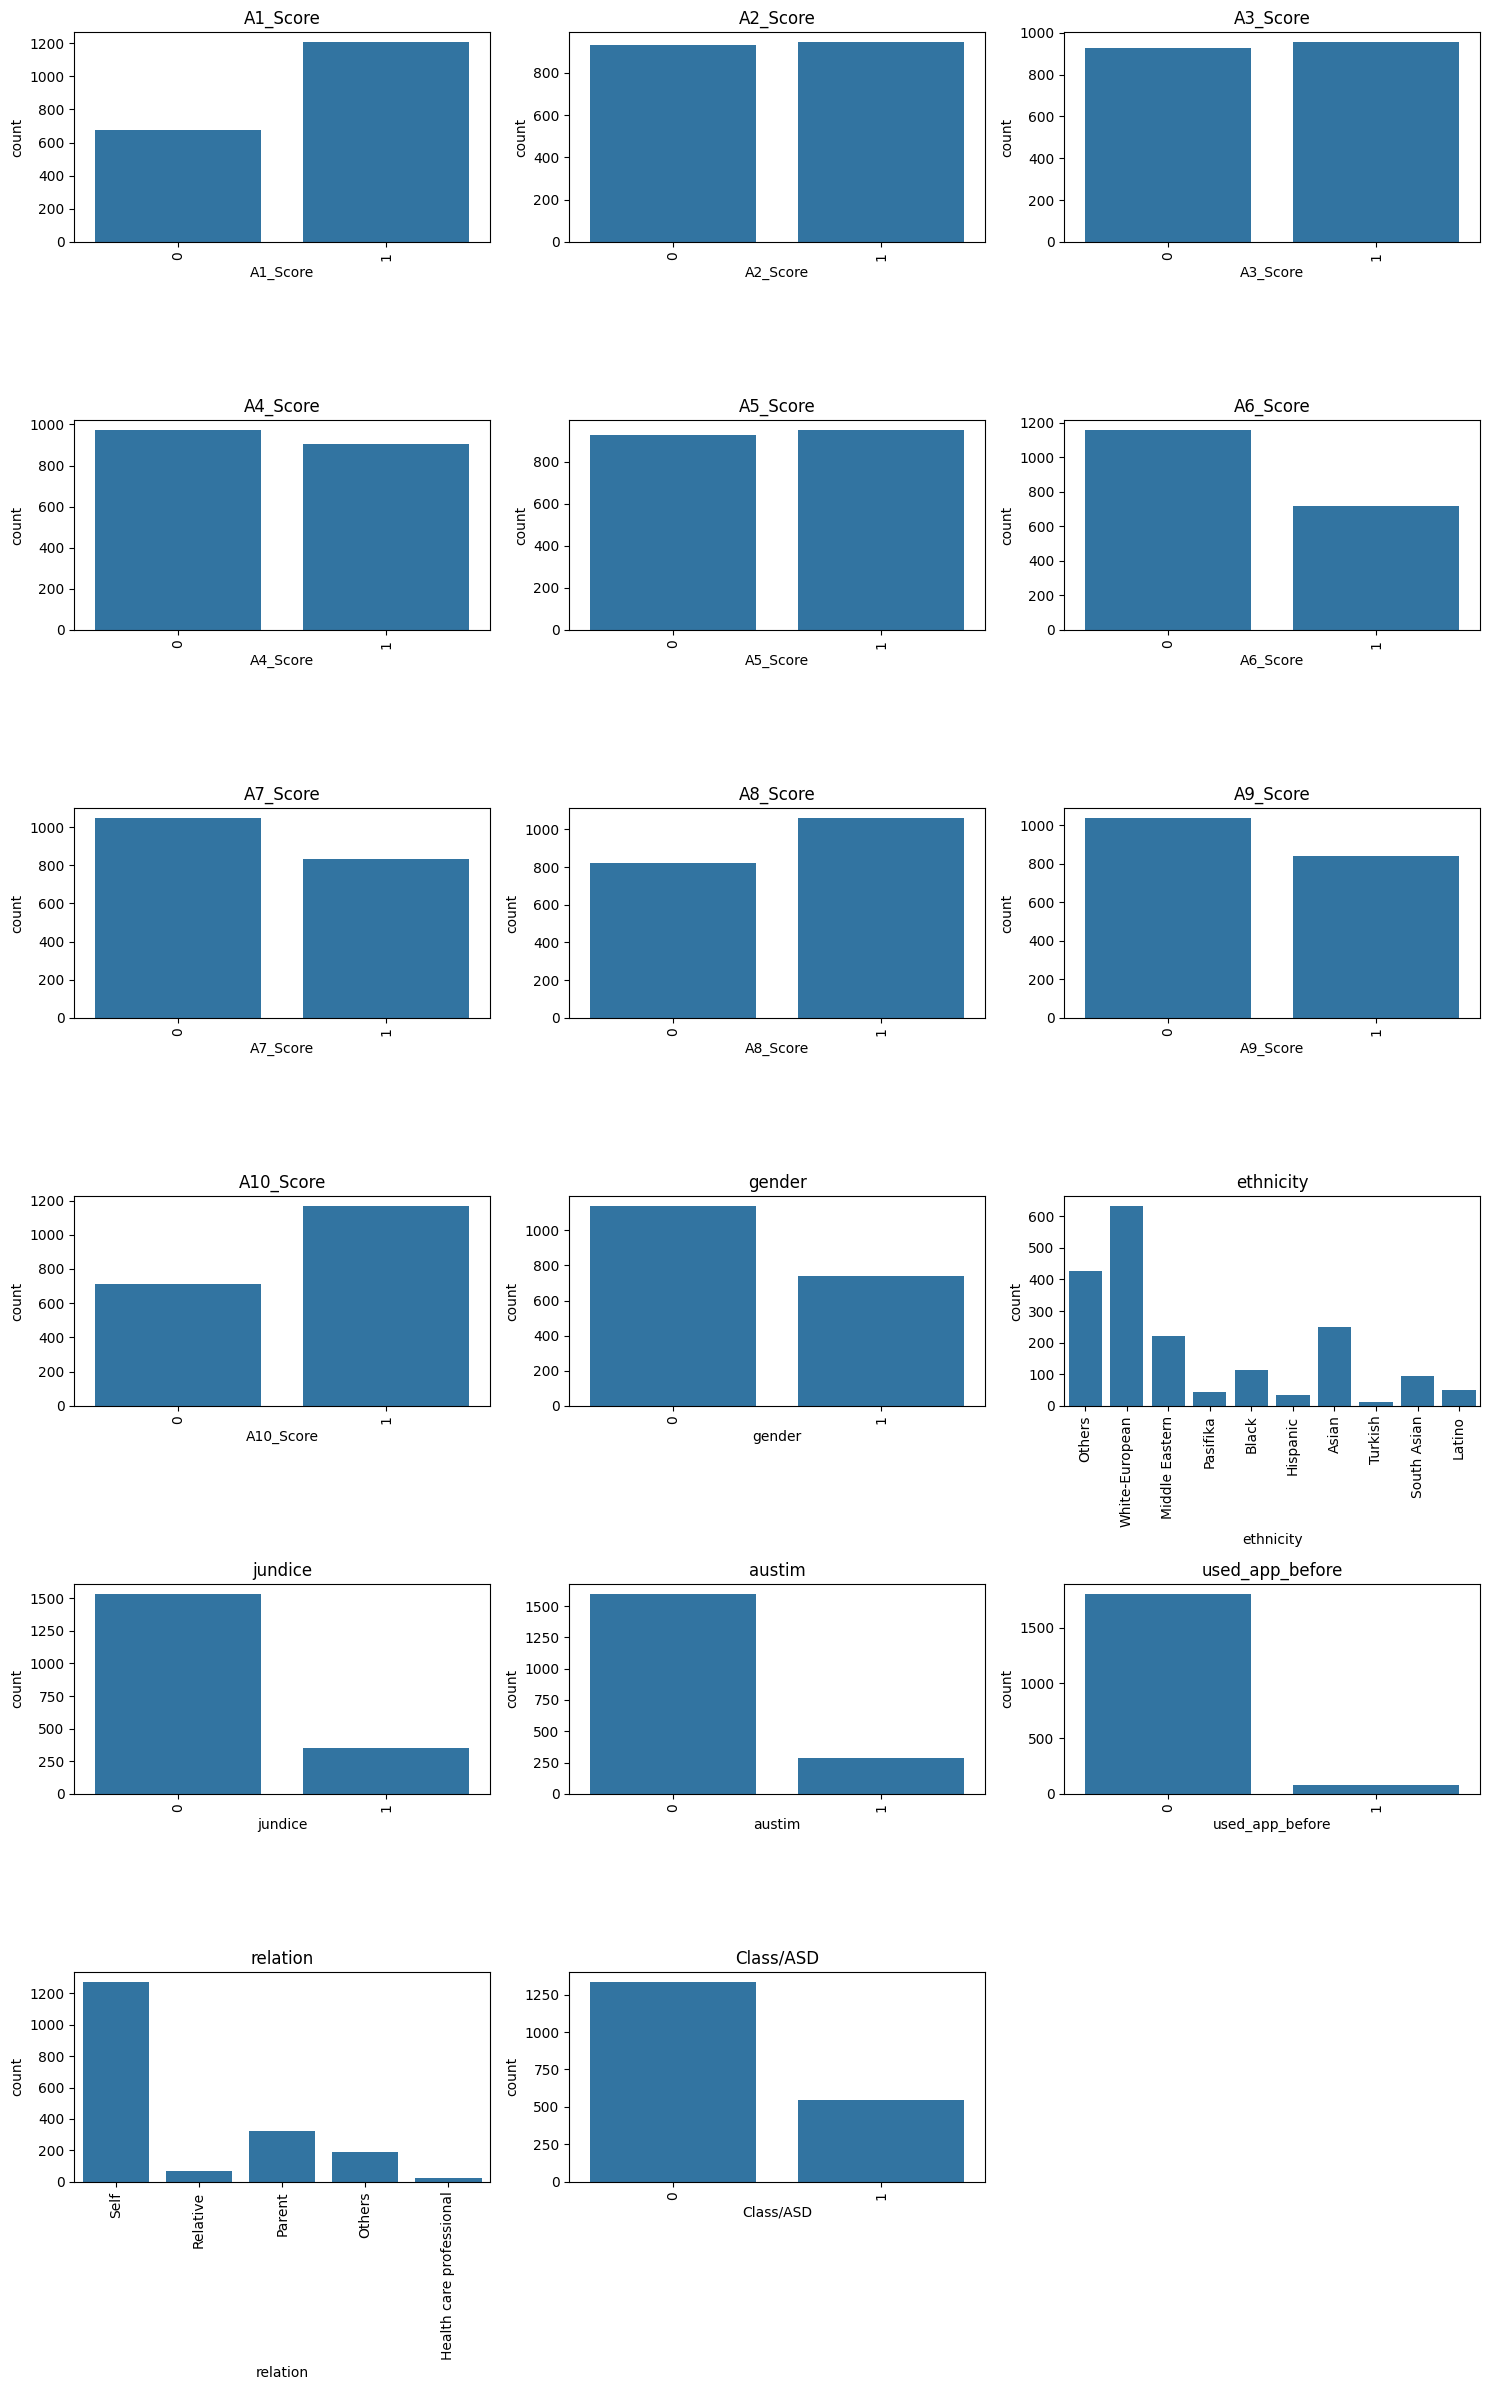

In [48]:
categorical_data = [
    'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
    'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
    'ethnicity', 'jundice', 'austim', 'used_app_before', 'relation', 'Class/ASD',
]

cols = 3
rows = math.ceil(len(categorical_data) / cols)
plt.figure(figsize=(15, 4 * rows))
for i, col in enumerate(categorical_data, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Text(0, 0.5, 'count')

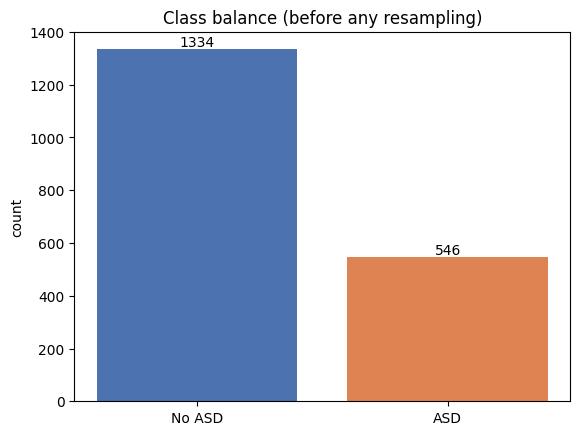

In [59]:
# Class balance check
ax = df["Class/ASD"].value_counts().rename({0: "No ASD", 1: "ASD"})
plt.bar_label(plt.bar(ax.index,ax.values, color=["#4C72B0", "#DD8452"]))
plt.title("Class balance (before any resampling)")
plt.ylabel("count")



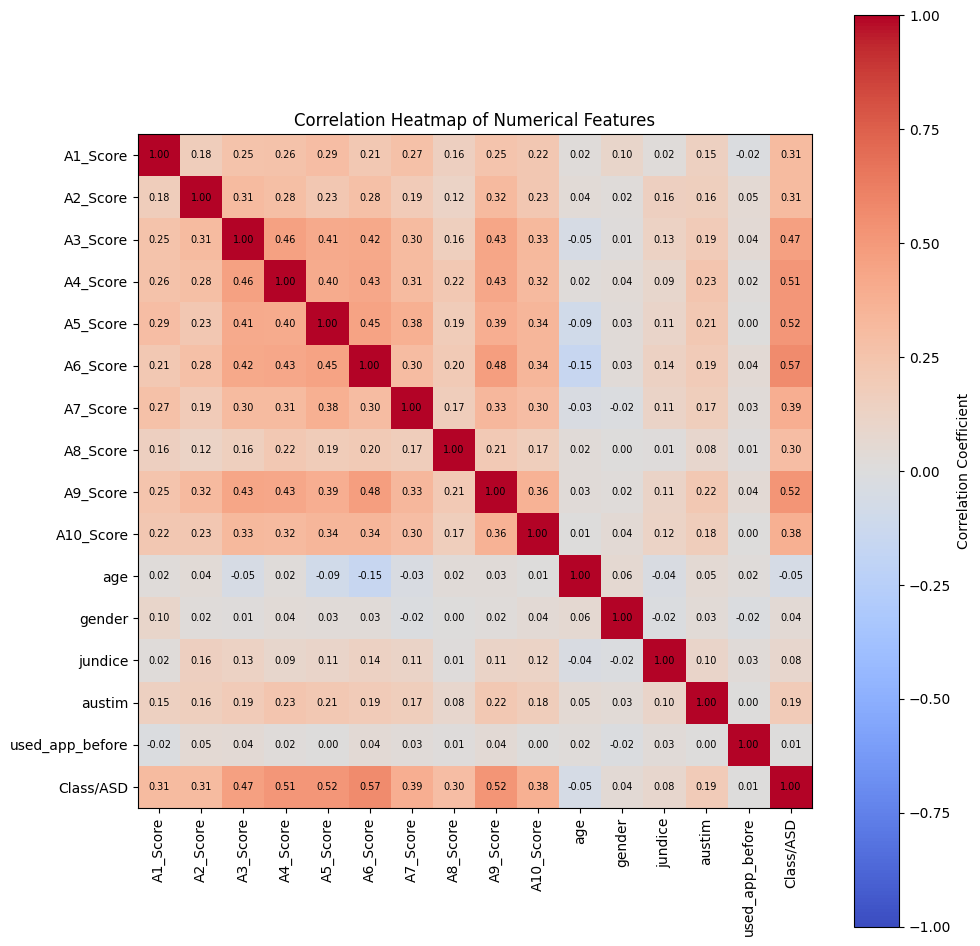

In [ ]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap to visualize relationships between numerical variables
plt.figure(figsize=(10, 10))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest",
    vmin=-1,
    vmax=1
)

# Add color bar to represent correlation values
plt.colorbar(label="Correlation Coefficient")

# Add feature names to axes
plt.xticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Display correlation values inside the heatmap
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

# Add chart title
plt.title("Correlation Heatmap of Numerical Features")

# Adjust layout for better visualization
plt.tight_layout()

# Display the heatmap
plt.show()

## 4. Train / test split

We split **before** doing anything about class imbalance, and we'll only apply SMOTE inside the training folds later (never to the test set), so evaluation stays honest.

In [51]:
X = df.drop(columns=["Class/ASD"])
y = df["Class/ASD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "positive_ratio": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])
display(split_summary.round(4))

assert len(X_train) + len(X_test) == len(df)
assert set(y_train.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}


,rows,positive_ratio
train,1504,0.2906
test,376,0.2899


## 5. Preprocessing + imbalance handling

- Numerical columns are standardized.
- Categorical columns are one-hot encoded.
- **SMOTE** generates synthetic minority-class (ASD) examples *inside the training pipeline only*, so it's automatically re-fit correctly on every cross-validation fold and never touches `X_test`.

This replaces the original notebook's approach of bootstrapping (duplicating with replacement) the minority class, which just repeats identical rows and encourages the model to overfit to those exact repeats instead of learning generalizable patterns.

In [52]:
cat_features = X_train.select_dtypes(include="object").columns.tolist()
num_features = [c for c in X_train.columns if c not in cat_features]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

print("Numerical features:", num_features)
print("Categorical features:", cat_features)


Numerical features: ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'jundice', 'austim', 'used_app_before']
Categorical features: ['ethnicity', 'contry_of_res', 'relation']


## 6. Train & tune candidate models

Each model is wrapped in a pipeline (`preprocess -> SMOTE -> classifier`) and tuned with 5-fold stratified cross-validation, optimizing F1 (a better metric than accuracy for imbalanced data).

In [53]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_space = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, random_state=42),
        {"classifier__C": [0.1, 0.5, 1.0, 2.0]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {"classifier__n_estimators": [200, 400], "classifier__max_depth": [None, 10, 20]},
    ),
    "SVM (RBF)": (
        SVC(kernel="rbf", probability=True, random_state=42),
        {"classifier__C": [1, 2, 5], "classifier__gamma": ["scale", "auto"]},
    ),
    "XGBoost": (
        XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1),
        {
            "classifier__n_estimators": [200, 300],
            "classifier__max_depth": [3, 4, 5],
            "classifier__learning_rate": [0.05, 0.1],
        },
    ),
}

results = []
fitted_models = {}
predictions = {}

for name, (clf, grid) in search_space.items():
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", clf),
    ])
    gs = GridSearchCV(pipe, grid, scoring="f1", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)

    pred = gs.predict(X_test)
    predictions[name] = pred
    fitted_models[name] = gs.best_estimator_

    results.append({
        "model": name,
        "best_params": gs.best_params_,
        "cv_f1": gs.best_score_,
        "test_accuracy": accuracy_score(y_test, pred),
        "test_precision": precision_score(y_test, pred),
        "test_recall": recall_score(y_test, pred),
        "test_f1": f1_score(y_test, pred),
    })
    print(f"Finished {name}: best_params={gs.best_params_}, cv_f1={gs.best_score_:.4f}")


Finished Logistic Regression: best_params={'classifier__C': 0.1}, cv_f1=0.8390
Finished Random Forest: best_params={'classifier__max_depth': 10, 'classifier__n_estimators': 200}, cv_f1=0.8216


c:\Users\asd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Finished SVM (RBF): best_params={'classifier__C': 1, 'classifier__gamma': 'auto'}, cv_f1=0.8371
Finished XGBoost: best_params={'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}, cv_f1=0.8283


In [54]:
validation_results = (
    pd.DataFrame(results)
    .set_index("model")
    .sort_values(by="test_f1", ascending=False)
)
display(validation_results.round(4))

best_model_name = validation_results.index[0]
best_model = fitted_models[best_model_name]
print("Selected model:", best_model_name)


,best_params,cv_f1,test_accuracy,test_precision,test_recall,test_f1
model,,,,,,
XGBoost,"{'classifier__learning_rate': 0.1, 'classifier...",0.8283,0.9229,0.8390,0.9083,0.8722
Logistic Regression,{'classifier__C': 0.1},0.8390,0.9149,0.7895,0.9633,0.8678
Random Forest,"{'classifier__max_depth': 10, 'classifier__n_e...",0.8216,0.9176,0.8197,0.9174,0.8658
SVM (RBF),"{'classifier__C': 1, 'classifier__gamma': 'auto'}",0.8371,0.9096,0.7737,0.9725,0.8618


Selected model: XGBoost


## 7. Evaluate the best model

=== XGBoost — classification report ===
              precision    recall  f1-score   support

           0      0.961     0.929     0.945       267
           1      0.839     0.908     0.872       109

    accuracy                          0.923       376
   macro avg      0.900     0.919     0.909       376
weighted avg      0.926     0.923     0.924       376



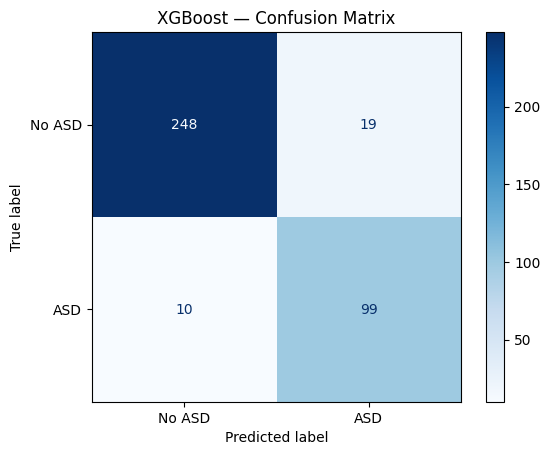

In [55]:
y_pred_best = predictions[best_model_name]

print(f"=== {best_model_name} — classification report ===")
print(classification_report(y_test, y_pred_best, digits=3))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No ASD", "ASD"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"{best_model_name} — Confusion Matrix")
plt.show()


In [56]:
# Side-by-side comparison of every tuned model on the untouched test set
for name in fitted_models:
    print(f"\n{name}")
    print(classification_report(y_test, predictions[name], digits=3))
    print("=" * 60)



Logistic Regression
              precision    recall  f1-score   support

           0      0.984     0.895     0.937       267
           1      0.789     0.963     0.868       109

    accuracy                          0.915       376
   macro avg      0.887     0.929     0.903       376
weighted avg      0.927     0.915     0.917       376


Random Forest
              precision    recall  f1-score   support

           0      0.965     0.918     0.940       267
           1      0.820     0.917     0.866       109

    accuracy                          0.918       376
   macro avg      0.892     0.918     0.903       376
weighted avg      0.923     0.918     0.919       376


SVM (RBF)
              precision    recall  f1-score   support

           0      0.987     0.884     0.933       267
           1      0.774     0.972     0.862       109

    accuracy                          0.910       376
   macro avg      0.881     0.928     0.897       376
weighted avg      0.925    

## 8. Save all the models

Every tuned candidate (Logistic Regression, Random Forest, SVM, XGBoost) is saved to its own file, not just the winner — useful if you want to compare them later, swap the "best" model for a different one (e.g. a faster or more interpretable model), or run an ensemble. Each saved object is the **full pipeline** (preprocessing + SMOTE + classifier), so any of them can be loaded and called with `.predict()` directly on raw data.

File names follow the pattern `asd_model_<model_name>.joblib`. The overall best model (by test F1) is additionally saved as `asd_best_model.joblib` for convenience.

In [57]:
import re

def slugify(name):
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")

saved_model_paths = {}
for name, model in fitted_models.items():
    path = f"asd_model_{slugify(name)}.joblib"
    joblib.dump(model, path)
    saved_model_paths[name] = path
    print(f"Saved {name:22s} -> {path}")

# Also save the overall best model under a fixed, convenient filename
joblib.dump(best_model, "asd_best_model.joblib")
saved_model_paths["Best (" + best_model_name + ")"] = "asd_best_model.joblib"
print(f"\nSaved best model ({best_model_name}) -> asd_best_model.joblib")

# Metadata: which file holds which model, plus features + test metrics for every model
metadata = {
    "best_model_name": best_model_name,
    "saved_model_paths": saved_model_paths,
    "features": list(X.columns),
    "categorical_features": cat_features,
    "numerical_features": num_features,
    "all_model_test_metrics": validation_results.round(4).to_dict(orient="index"),
}
joblib.dump(metadata, "asd_model_metadata.joblib")
print("Saved metadata -> asd_model_metadata.joblib")


Saved Logistic Regression    -> asd_model_logistic_regression.joblib
Saved Random Forest          -> asd_model_random_forest.joblib
Saved SVM (RBF)              -> asd_model_svm_rbf.joblib
Saved XGBoost                -> asd_model_xgboost.joblib

Saved best model (XGBoost) -> asd_best_model.joblib
Saved metadata -> asd_model_metadata.joblib


## 9. Load a saved model back and predict on a new patient

This demonstrates the full deployment loop: load any saved pipeline (the best one, or a specific candidate) and feed it one raw row shaped like the original data.

In [58]:
metadata = joblib.load("asd_model_metadata.joblib")
print("Available saved models:")
for name, path in metadata["saved_model_paths"].items():
    print(f"  - {name:28s} -> {path}")

# Load whichever one you want — defaults to the best model
loaded_model = joblib.load("asd_best_model.joblib")

# Example new patient (raw, un-encoded values -- the pipeline handles everything)
new_patient = pd.DataFrame([{
    "A1_Score": 1, "A2_Score": 1, "A3_Score": 0, "A4_Score": 1, "A5_Score": 1,
    "A6_Score": 0, "A7_Score": 1, "A8_Score": 1, "A9_Score": 0, "A10_Score": 1,
    "age": 27, "gender": 1, "ethnicity": "White-European", "jundice": 0,
    "austim": 0, "contry_of_res": "United States", "used_app_before": 0,
    "relation": "Self",
}])

pred = loaded_model.predict(new_patient)[0]
proba = loaded_model.predict_proba(new_patient)[0][1] if hasattr(loaded_model, "predict_proba") else None

print("\nPrediction:", "ASD traits likely" if pred == 1 else "ASD traits unlikely")
if proba is not None:
    print(f"Predicted probability of ASD traits: {proba:.3f}")

# Example: load a *different* saved model (Logistic Regression) and compare
lr_path = metadata["saved_model_paths"]["Logistic Regression"]
loaded_lr = joblib.load(lr_path)
lr_pred = loaded_lr.predict(new_patient)[0]
print(f"\nLogistic Regression prediction on same patient: {'ASD traits likely' if lr_pred == 1 else 'ASD traits unlikely'}")


Available saved models:
  - Logistic Regression          -> asd_model_logistic_regression.joblib
  - Random Forest                -> asd_model_random_forest.joblib
  - SVM (RBF)                    -> asd_model_svm_rbf.joblib
  - XGBoost                      -> asd_model_xgboost.joblib
  - Best (XGBoost)               -> asd_best_model.joblib

Prediction: ASD traits likely
Predicted probability of ASD traits: 0.654

Logistic Regression prediction on same patient: ASD traits likely


## Summary

- **Data loading** now works fully offline from the uploaded files.
- **Version-compatibility fix**: added a setup cell (section 0) that upgrades `scikit-learn`/`imbalanced-learn` together, fixing the `'Pipeline' object has no attribute '_check_fit_params'` crash caused by mismatched versions.
- **Imbalance** is handled with SMOTE inside the training pipeline instead of naive row duplication, which avoids overfitting to repeated rows.
- **Accuracy is now realistic** (~92% accuracy, ~0.87 F1 on the minority ASD class) after removing the redundant `result`/`result_check` column and restoring useful features (`age`, `gender`, `jundice`, `used_app_before`) that were previously dropped.
- **Hyperparameters are tuned** with cross-validated grid search across 4 model families.
- **Every tuned model is saved individually** (`asd_model_<name>.joblib`), plus the best one is saved separately as `asd_best_model.joblib`, with a metadata file (`asd_model_metadata.joblib`) mapping model names to their saved file paths and recording each model's test metrics.
- Reloading any saved model and predicting on new data is demonstrated end-to-end.
